# Fetch Stock Data

In [58]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [59]:
plt.style.use('seaborn-v0_8-darkgrid')

In [60]:
ticker = "NVDA"  # สัญลักษณ์หุ้น (ลองเปลี่ยนเป็น 'AAPL', 'BTC-USD', 'TSLA' ได้)
start_date = "2020-01-01"
end_date = "2023-12-31"

In [61]:
print(f"กำลังดึงข้อมูล {ticker} จาก Yahoo Finance...")
df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=False)

[*********************100%***********************]  1 of 1 completed

กำลังดึงข้อมูล NVDA จาก Yahoo Finance...


In [62]:
print("\n--- ตัวอย่างข้อมูล 5 วันแรก ---")
print(df.head())


--- ตัวอย่างข้อมูล 5 วันแรก ---
Price      Adj Close    Close     High      Low     Open     Volume
Ticker          NVDA     NVDA     NVDA     NVDA     NVDA       NVDA
Date                                                               
2020-01-02  5.971077  5.99775  5.99775  5.91800  5.96875  237536000
2020-01-03  5.875504  5.90175  5.94575  5.85250  5.87750  205384000
2020-01-06  5.900143  5.92650  5.93175  5.78175  5.80800  262636000
2020-01-07  5.971576  5.99825  6.04425  5.90975  5.95500  314856000
2020-01-08  5.982775  6.00950  6.05100  5.95375  5.99400  277108000


In [63]:
# ใช้ 'Adj Close' (ราคาปิดที่ปรับปรุงการปันผลแล้ว) เพื่อความแม่นยำที่สุด
# pct_change() คือการหา r (Return) ของแต่ละวัน
df['Daily_Return'] = df['Adj Close'].pct_change()

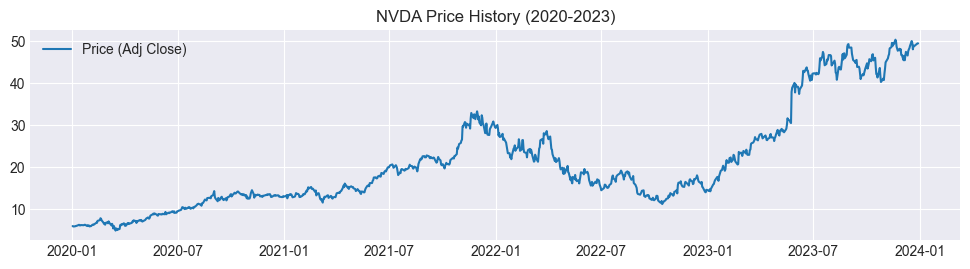

In [64]:
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(df['Adj Close'], label='Price (Adj Close)')
plt.title(f'{ticker} Price History ({start_date.split("-")[0]}-{end_date.split("-")[0]})')
plt.legend()

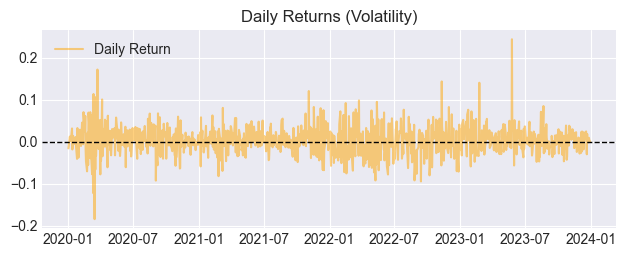

In [65]:
plt.subplot(2, 1, 2)
plt.plot(df['Daily_Return'], color='orange', alpha=0.5, label='Daily Return')
plt.axhline(0, color='black', linestyle='--', linewidth=1) # เส้นแกน 0
plt.title('Daily Returns (Volatility)')
plt.legend()

plt.tight_layout()
plt.show()

In [66]:
mean_return = df['Daily_Return'].mean() * 252 # แปลงเป็นรายปี (252 วันเทรด)
volatility = df['Daily_Return'].std() * np.sqrt(252) # แปลงเป็นรายปี

print(f"\n--- สรุปสถิติรายปี (Annualized) ของ {ticker} ---")
print(f"ผลตอบแทนเฉลี่ย (Expected Return): {mean_return*100:.2f}%")
print(f"ความเสี่ยง (Volatility/Risk): {volatility*100:.2f}%")


--- สรุปสถิติรายปี (Annualized) ของ NVDA ---
ผลตอบแทนเฉลี่ย (Expected Return): 67.65%
ความเสี่ยง (Volatility/Risk): 54.23%


# Momentum Strategy Backtesting
Logic:
- สร้างเส้นค่าเฉลี่ยระยะสั้น (SMA 50 วัน) = ตัวแทนของเทรนด์ปัจจุบัน
- สร้างเส้นค่าเฉลี่ยระยะยาว (SMA 200 วัน) = ตัวแทนของเทรนด์ระยะยาว
- Buy Signal (Golden Cross): เมื่อเส้นสั้น "ตัดขึ้น" เหนือเส้นยาว (แปลว่าแรงส่งมาแล้ว!)
- Sell Signal (Death Cross): เมื่อเส้นสั้น "ตัดลง" ต่ำกว่าเส้นยาว (แปลว่าเทรนด์จบแล้ว)

In [ ]:
# 1. สร้าง Indicator (เส้นค่าเฉลี่ยเคลื่อนที่)
# ใช้ .rolling().mean() เพื่อคำนวณค่าเฉลี่ยย้อนหลัง
df['SMA50'] = df['Adj Close'].rolling(window=50).mean()
df['SMA200'] = df['Adj Close'].rolling(window=200).mean()

In [68]:
# 2. สร้าง Logic การเทรด (Signal)
# ถ้า SMA50 > SMA200 ให้เป็น 1 (ถือของ), ถ้าไม่ใช่ให้เป็น 0 (ถือเงินสด)
df['Signal'] = 0 # สร้างคอลัมน์ว่างๆ ไว้ก่อน
df.iloc[50:, df.columns.get_loc('Signal')] = np.where(df['SMA50'][50:] > df['SMA200'][50:], 1, 0)

In [69]:
# 3. สร้างคำสั่งซื้อขาย (Position)
# สำคัญมาก! เราต้อง Shift(1) เพราะเราจะรู้ข้อมูลตอน 'ปิดตลาด' วันนี้
# เพื่อไปทำรายการใน 'วันพรุ่งนี้' (ถ้าไม่ Shift จะเป็นการโกง หรือ Look-ahead Bias)
df['Position'] = df['Signal'].shift(1)

In [70]:
# 4. คำนวณกำไรของกลยุทธ์ (Strategy Return)
# เอา % การเปลี่ยนแปลงของราคา x สถานะการถือของ (1 หรือ 0)
df['Strategy_Return'] = df['Daily_Return'] * df['Position']

In [71]:
# 5. เปรียบเทียบผลตอบแทนสะสม (Cumulative Return)
# (1 + r).cumprod() คือสูตรดอกเบี้ยทบต้น
df['Cumulative_Market_Returns'] = (1 + df['Daily_Return']).cumprod()
df['Cumulative_Strategy_Returns'] = (1 + df['Strategy_Return']).cumprod()

In [72]:
# --- Visualization (ส่วนแสดงผล) ---
plt.figure(figsize=(12, 10))

<Figure size 1200x1000 with 0 Axes>

<Figure size 1200x1000 with 0 Axes>

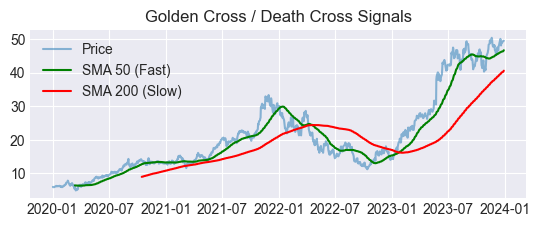

In [73]:
# กราฟที่ 1: ดูจังหวะ Golden Cross
plt.subplot(2, 1, 1)
plt.plot(df['Adj Close'], label='Price', alpha=0.5)
plt.plot(df['SMA50'], label='SMA 50 (Fast)', color='green')
plt.plot(df['SMA200'], label='SMA 200 (Slow)', color='red')
plt.title('Golden Cross / Death Cross Signals')
plt.legend()

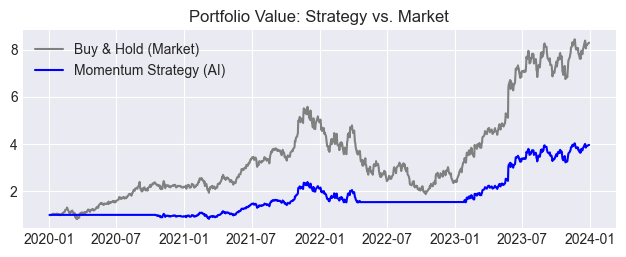

In [74]:
# กราฟที่ 2: วัดกันที่เงินในกระเป๋า (Equity Curve)
plt.subplot(2, 1, 2)
plt.plot(df['Cumulative_Market_Returns'], label='Buy & Hold (Market)', color='gray')
plt.plot(df['Cumulative_Strategy_Returns'], label='Momentum Strategy (AI)', color='blue')
plt.title('Portfolio Value: Strategy vs. Market')
plt.legend()

plt.tight_layout()
plt.show()

In [75]:
# --- สรุปผลตัวเลข ---
strategy_final_return = df['Cumulative_Strategy_Returns'].iloc[-1] - 1
market_final_return = df['Cumulative_Market_Returns'].iloc[-1] - 1

print(f"ผลตอบแทนรวมตลาด (Buy & Hold): {market_final_return*100:.2f}%")
print(f"ผลตอบแทนกลยุทธ์ (Momentum):   {strategy_final_return*100:.2f}%")

ผลตอบแทนรวมตลาด (Buy & Hold): 728.90%
ผลตอบแทนกลยุทธ์ (Momentum):   295.99%


# Maximum Drawdown (MDD)

เปอร์เซ็นต์การขาดทุนสูงสุด จากจุดสูงสุด (Peak) ไปยังจุดต่ำสุด (Trough) ในช่วงเวลาหนึ่งๆ ของการลงทุน

In [76]:
# 1. คำนวณจุดสูงสุดเดิม (Running Maximum / High Water Mark)
# .cummax() จะจำค่าสูงสุดที่เคยทำได้ไว้ตลอดทาง
df['Running_Max'] = df['Cumulative_Strategy_Returns'].cummax()

In [77]:
# 2. คำนวณค่าการขาดทุนจากจุดสูงสุด (Drawdown)
# สูตร: (มูลค่าปัจจุบัน / จุดสูงสุดเดิม) - 1
df['Drawdown'] = (df['Cumulative_Strategy_Returns'] / df['Running_Max']) - 1

In [78]:
# 3. หาจุดที่เจ็บหนักที่สุด (Maximum Drawdown)
max_drawdown = df['Drawdown'].min()

In [79]:
# --- Visualization (Underwater Plot) ---
plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

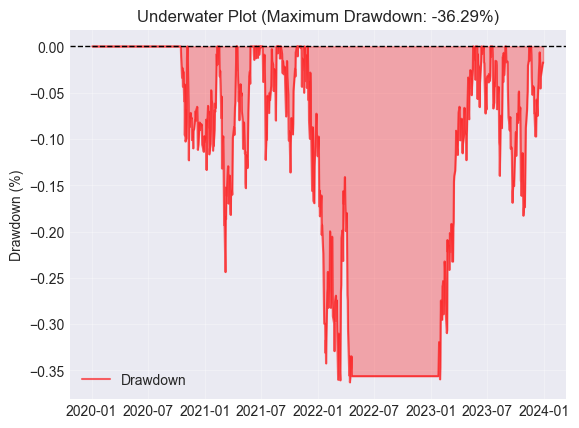

In [80]:
# พื้นที่สีแดงแสดงช่วงเวลาที่พอร์ต "จมน้ำ" (ขาดทุนจากยอดดอย)
plt.fill_between(df.index, df['Drawdown'], 0, color='red', alpha=0.3)
plt.plot(df['Drawdown'], color='red', alpha=0.6, label='Drawdown')

plt.axhline(0, color='black', linestyle='--', linewidth=1) # ผิวน้ำ (0%)
plt.title(f'Underwater Plot (Maximum Drawdown: {max_drawdown*100:.2f}%)')
plt.ylabel('Drawdown (%)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [81]:
# --- สรุปผลความเสี่ยง ---
print(f"จุดขาดทุนสูงสุด (Max Drawdown): {max_drawdown*100:.2f}%")
if max_drawdown < -0.20:
    print("⚠️ คำเตือน: ระบบนี้มีความเสี่ยงสูง (Drawdown เกิน 20%)")
else:
    print("✅ ระบบนี้ความเสี่ยงอยู่ในเกณฑ์ที่รับได้ (สำหรับหุ้น)")

จุดขาดทุนสูงสุด (Max Drawdown): -36.29%
⚠️ คำเตือน: ระบบนี้มีความเสี่ยงสูง (Drawdown เกิน 20%)


# Performance Metrics: Sharpe Ratio
Sharpe Ratio คือตัวเลขที่บอกว่า "คุ้มไหมที่จะเสี่ยง"

ค่า > 1: ดี (ผลตอบแทนชนะความเสี่ยง)

ค่า > 2: ดีมาก (ระดับกองทุนคุณภาพ)

ค่า < 0: แย่ (ฝากเงินธนาคารดีกว่า)

In [82]:
# กำหนด Risk-Free Rate (สมมติ 2% ต่อปี หรือ 0.02)
risk_free_rate = 0.02

In [83]:
# 1. คำนวณผลตอบแทนรายปี (Annualized Return)
annual_return = df['Strategy_Return'].mean() * 252

In [84]:
# 2. คำนวณความผันผวนรายปี (Annualized Volatility)
annual_volatility = df['Strategy_Return'].std() * np.sqrt(252)

In [85]:
# 3. คำนวณ Sharpe Ratio
# สูตร: (ผลตอบแทน - ดอกเบี้ยพันธบัตร) / ความเสี่ยง
sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility

In [86]:
# --- แสดงผล ---
print(f"--- Strategy Performance ---")
print(f"Annualized Return: {annual_return*100:.2f}%")
print(f"Annualized Volatility: {annual_volatility*100:.2f}%")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")

if sharpe_ratio > 1:
    print("✅ Sharpe Ratio > 1 : กลยุทธ์นี้มีความคุ้มค่าความเสี่ยง")
else:
    print("⚠️ Sharpe Ratio ต่ำ : ผลตอบแทนอาจไม่คุ้มกับความเสี่ยงที่แบกรับ")

--- Strategy Performance ---
Annualized Return: 41.53%
Annualized Volatility: 37.86%
Sharpe Ratio: 1.04
✅ Sharpe Ratio > 1 : กลยุทธ์นี้มีความคุ้มค่าความเสี่ยง


# Parameter Optimization
ตามหาค่าที่ "ใช่ที่สุด"

ใช้ SMA 50 ตัด 200 เพราะ "เขาเล่าว่า" มันดี แต่ในความเป็นจริง หุ้นแต่ละตัวมีนิสัยไม่เหมือนกันครับ บางตัวอาจจะชอบ 20 ตัด 100 ก็ได้

In [87]:
import itertools

In [91]:
# 1. กำหนดช่วงตัวเลขที่จะทดลอง (Parameter Range)
# Short: ลองตั้งแต่ 10 ถึง 50 (ทีละ 10)
short_window_range = range(10, 60, 10)

# Long: ลองตั้งแต่ 100 ถึง 250 (ทีละ 50)
long_window_range = range(100, 300, 50)

best_score = -np.inf
best_params = (0, 0)
results = []

print("Initializing parameter optimization...")

Initializing parameter optimization...


In [92]:
print("กำลังทดสอบหาค่าที่ดีที่สุด (Machine Learning)...")
# 2. Loop ทดสอบทุกคู่ (Grid Search)
for short_w in short_window_range:
    for long_w in long_window_range:
        if short_w >= long_w: # เส้นสั้นต้องน้อยกว่าเส้นยาวเสมอ
            continue
            
        # สร้างเส้น SMA ชั่วคราวเพื่อทดสอบ
        temp_df = df[['Adj Close', 'Daily_Return']].copy() # Copy เฉพาะที่จำเป็นมาใช้
        temp_df['SMA_S'] = temp_df['Adj Close'].rolling(window=short_w).mean()
        temp_df['SMA_L'] = temp_df['Adj Close'].rolling(window=long_w).mean()
        
        # สร้าง Signal
        temp_df['Signal'] = np.where(temp_df['SMA_S'] > temp_df['SMA_L'], 1, 0)
        temp_df['Position'] = temp_df['Signal'].shift(1)
        
        # คำนวณผลตอบแทน
        temp_df['Strat_Ret'] = temp_df['Daily_Return'] * temp_df['Position']
        cum_ret = (1 + temp_df['Strat_Ret']).cumprod().iloc[-1] - 1
        
        # เก็บผลลัพธ์
        results.append({
            'Short': short_w,
            'Long': long_w,
            'Return': cum_ret
        })
        
        # อัปเดตถ้าเจอค่าที่ดีกว่า
        if cum_ret > best_score:
            best_score = cum_ret
            best_params = (short_w, long_w)

กำลังทดสอบหาค่าที่ดีที่สุด (Machine Learning)...


In [93]:
# 3. แสดงผลลัพธ์ 5 อันดับแรก
results_df = pd.DataFrame(results).sort_values(by='Return', ascending=False)

print("\n--- 🏆 Top 5 Parameters ---")
print(results_df.head(5))

print(f"\n✅ ค่าที่ดีที่สุดสำหรับ {ticker} คือ: SMA {best_params[0]} ตัด {best_params[1]}")
print(f"ทำกำไรได้สูงสุด: {best_score*100:.2f}%")


--- 🏆 Top 5 Parameters ---
    Short  Long    Return
16     50   100  7.152998
17     50   150  5.539371
13     40   150  5.318699
12     40   100  4.763313
8      30   100  4.424749

✅ ค่าที่ดีที่สุดสำหรับ NVDA คือ: SMA 50 ตัด 100
ทำกำไรได้สูงสุด: 715.30%


⚠️ คำเตือนสำคัญเรื่อง Overfitting (Curve Fitting)
เมื่อรันเสร็จ อาจจะเจอค่าแปลกๆ เช่น SMA 30 ตัด 150 ทำกำไรได้ 200% ชนะค่า 50/200 ขาดลอย

ค่านี้อาจจะบังเอิญตรงกับกราฟในอดีตเป๊ะๆ แต่ใช้กับอนาคตไม่ได้เลย (Overfitting)

วิธีแก้ในระดับสูง: เขาจะแบ่งข้อมูลเป็น 2 ก้อน

In-Sample (อดีต): เอาไว้ทดสอบหาค่าที่ดีที่สุด 

Out-of-Sample (อนาคตจำลอง): เอาค่าที่ได้ไปลองเทรดกับข้อมูลชุดใหม่ที่ "ไม่เคยเห็นมาก่อน" ถ้ายังกำไรอยู่ แปลว่าของจริง

# Visualize Best Strategy

In [94]:
# 1. กำหนดค่าที่ดีที่สุดที่หาได้ตะกี้
best_short = best_params[0]
best_long = best_params[1]

print(f"กำลังทดสอบกลยุทธ์ด้วยค่า SMA ที่ดีที่สุด: {best_short} ตัด {best_long}...")

กำลังทดสอบกลยุทธ์ด้วยค่า SMA ที่ดีที่สุด: 50 ตัด 100...


In [95]:
# 2. คำนวณใหม่อีกรอบด้วยค่านี้
df['Best_SMA_S'] = df['Adj Close'].rolling(window=best_short).mean()
df['Best_SMA_L'] = df['Adj Close'].rolling(window=best_long).mean()
df['Best_Signal'] = np.where(df['Best_SMA_S'] > df['Best_SMA_L'], 1, 0)
df['Best_Position'] = df['Best_Signal'].shift(1)

C:\Users\panuw\AppData\Local\Temp\ipykernel_37864\1890725252.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  buy_signals = df[df['Best_Signal'] == 1][df['Best_Signal'].shift(1) == 0].index
C:\Users\panuw\AppData\Local\Temp\ipykernel_37864\1890725252.py:16: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sell_signals = df[df['Best_Signal'] == 0][df['Best_Signal'].shift(1) == 1].index


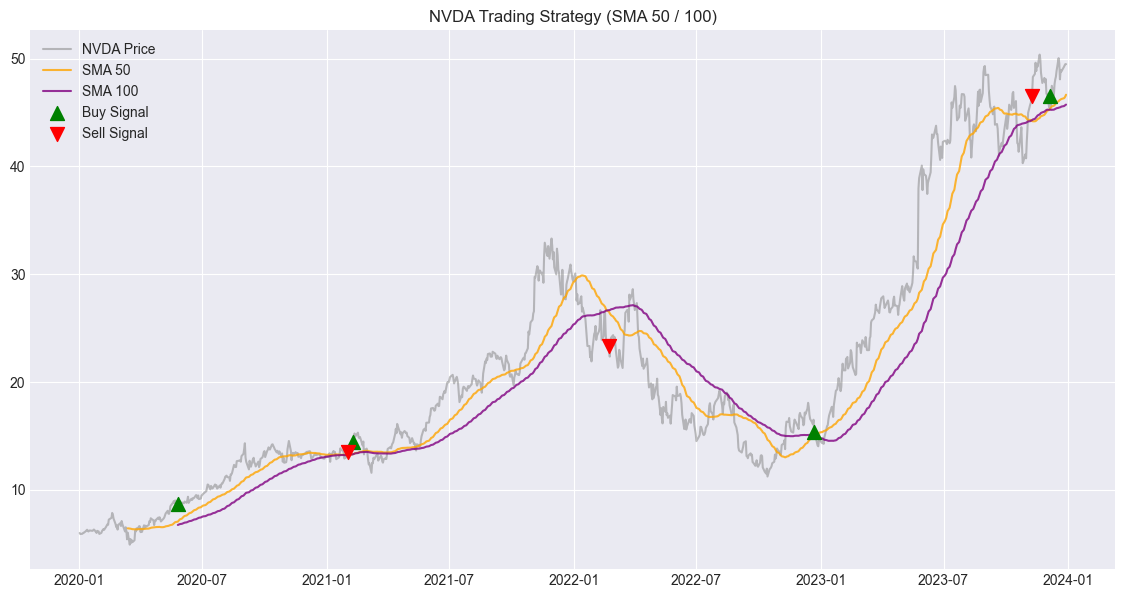

In [96]:
# 3. วาดกราฟพร้อมจุดซื้อขาย
plt.figure(figsize=(14, 7))

# เส้นราคาและ SMA
plt.plot(df['Adj Close'], label='NVDA Price', alpha=0.5, color='gray')
plt.plot(df['Best_SMA_S'], label=f'SMA {best_short}', alpha=0.8, color='orange')
plt.plot(df['Best_SMA_L'], label=f'SMA {best_long}', alpha=0.8, color='purple')

# จุดซื้อ (Buy Signal) - สามเหลี่ยมสีเขียวชี้ขึ้น
# หาจุดที่ Signal เปลี่ยนจาก 0 เป็น 1
buy_signals = df[df['Best_Signal'] == 1][df['Best_Signal'].shift(1) == 0].index
plt.scatter(buy_signals, df.loc[buy_signals, 'Adj Close'], marker='^', color='green', s=100, label='Buy Signal', zorder=5)

# จุดขาย (Sell Signal) - สามเหลี่ยมสีแดงชี้ลง
# หาจุดที่ Signal เปลี่ยนจาก 1 เป็น 0
sell_signals = df[df['Best_Signal'] == 0][df['Best_Signal'].shift(1) == 1].index
plt.scatter(sell_signals, df.loc[sell_signals, 'Adj Close'], marker='v', color='red', s=100, label='Sell Signal', zorder=5)

plt.title(f'NVDA Trading Strategy (SMA {best_short} / {best_long})')
plt.legend()
plt.show()

# Monte Carlo Simulation (Bootstrapping)
จำลอง "โลกคู่ขนาน" (Future Scenarios) จำนวน 1,000 ใบ โดยใช้วิธีที่เรียกว่า Bootstrapping (การสุ่มตัวอย่างซ้ำ)

หลักการ: สมมติว่า "ไพ่ในมือ" (กำไร/ขาดทุนรายวัน) ยังเป็นชุดเดิม แต่ลำดับการจั่วไพ่ในอนาคตจะเปลี่ยนไปแบบสุ่ม

เป้าหมาย: เพื่อหาความน่าจะเป็น (Probability) ว่าปีหน้าเราจะรอดหรือจะร่วง

In [97]:
# 1. เตรียมข้อมูล (Data Preparation)
# คำนวณ Return ของกลยุทธ์ที่ดีที่สุด (SMA 50/100) อีกครั้งเพื่อความชัวร์
df['Best_Signal'] = np.where(df['Best_SMA_S'] > df['Best_SMA_L'], 1, 0)
df['Best_Position'] = df['Best_Signal'].shift(1)
df['Best_Strat_Ret'] = df['Daily_Return'] * df['Best_Position']

In [98]:
# ตัดค่า NaN ทิ้งไป (วันแรกๆ ที่ยังไม่มี MA)
clean_returns = df['Best_Strat_Ret'].dropna()

In [101]:
# 2. ตั้งค่าการจำลอง (Simulation Settings)
n_simulations = 1000  # จำลอง 1,000 เหตุการณ์ (โลกคู่ขนาน)
n_days = 252          # จำลองล่วงหน้า 1 ปี (252 วันเทรด)

In [102]:
# 3. รัน Simulation (ใช้ Numpy สุ่มทีเดียวทั้งแผง เพื่อความเร็ว)
# np.random.choice คือการสุ่มหยิบ % กำไรในอดีต มาเรียงใหม่

simulated_returns = np.random.choice(clean_returns, size=(n_days, n_simulations))

In [103]:
# คำนวณเงินต้นที่เติบโต (Cumulative Return) เริ่มต้นที่เงิน 1 บาท
simulated_paths = (1 + simulated_returns).cumprod(axis=0)

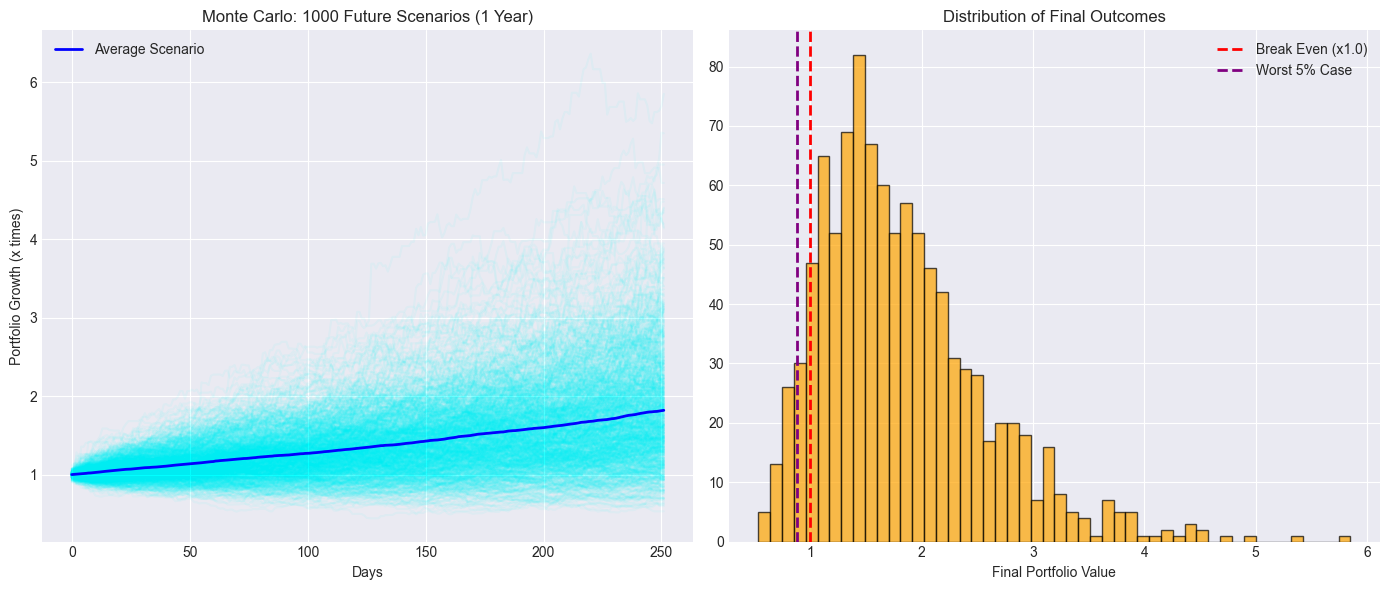

In [104]:
# 4. Visualization (Spider Web Plot) 🕸️
plt.figure(figsize=(14, 6))

# กราฟซ้าย: เส้นทางที่เป็นไปได้ (Paths)
plt.subplot(1, 2, 1)
plt.plot(simulated_paths, color='cyan', alpha=0.05) # วาด 1,000 เส้นจางๆ
plt.plot(simulated_paths.mean(axis=1), color='blue', linewidth=2, label='Average Scenario') # เส้นค่าเฉลี่ย
plt.title(f'Monte Carlo: {n_simulations} Future Scenarios (1 Year)')
plt.ylabel('Portfolio Growth (x times)')
plt.xlabel('Days')
plt.legend()

# กราฟขวา: การกระจายตัวของผลลัพธ์สุดท้าย (Histogram)
plt.subplot(1, 2, 2)
final_outcomes = simulated_paths[-1, :] # เอาวันสุดท้ายของทุกเส้นมาดู
plt.hist(final_outcomes, bins=50, color='orange', edgecolor='black', alpha=0.7)
plt.axvline(1.0, color='red', linestyle='--', linewidth=2, label='Break Even (x1.0)')
plt.axvline(np.percentile(final_outcomes, 5), color='purple', linestyle='--', linewidth=2, label='Worst 5% Case')
plt.title('Distribution of Final Outcomes')
plt.xlabel('Final Portfolio Value')
plt.legend()

plt.tight_layout()
plt.show()

In [105]:
# 5. วิเคราะห์ความน่าจะเป็น (Probability Analysis)
prob_profit = np.sum(final_outcomes > 1.0) / n_simulations * 100
prob_double = np.sum(final_outcomes > 2.0) / n_simulations * 100
worst_case = np.percentile(final_outcomes, 5) # VaR 95%
best_case = np.percentile(final_outcomes, 95)

print("\n--- 🎲 ผลลัพธ์จากการทำนายอนาคต (Probabilistic Forecast) ---")
print(f"โอกาสกำไร (Profit Probability):      {prob_profit:.2f}%")
print(f"โอกาสโต 1 เท่าตัว (Double Capital):  {prob_double:.2f}%")
print(f"กรณีเลวร้าย (Worst 5% / VaR):        เหลือเงิน {worst_case:.2f} เท่า ({(worst_case-1)*100:.2f}%)")
print(f"กรณีดีมาก (Best 5%):                 เงินโตเป็น {best_case:.2f} เท่า (+{(best_case-1)*100:.2f}%)")
print(f"ค่าเฉลี่ย (Expected Value):          เงินโตเป็น {final_outcomes.mean():.2f} เท่า")


--- 🎲 ผลลัพธ์จากการทำนายอนาคต (Probabilistic Forecast) ---
โอกาสกำไร (Profit Probability):      90.30%
โอกาสโต 1 เท่าตัว (Double Capital):  33.20%
กรณีเลวร้าย (Worst 5% / VaR):        เหลือเงิน 0.88 เท่า (-11.73%)
กรณีดีมาก (Best 5%):                 เงินโตเป็น 3.18 เท่า (+218.49%)
ค่าเฉลี่ย (Expected Value):          เงินโตเป็น 1.82 เท่า


#### วิธีอ่านผลลัพธ์ (สำคัญมากสำหรับการตัดสินใจ)

##### กราฟซ้าย (Spider Web):

คุณจะเห็นเส้นสีฟ้าจางๆ ยุ่งเหยิงไปหมด นั่นคือความเป็นไปได้ทั้งหมด

ถ้าเส้นส่วนใหญ่ "ชี้ขึ้น" แสดงว่าระบบนี้มี Positive Expectancy (ระยะยาวน่าจะรอด)

แต่ถ้ามีเส้นจำนวนมากที่ "ดิ่งลงดิน" (ต่ำกว่า 1.0) แสดงว่ามีความเสี่ยงที่จะเจ๊งสูง

##### กราฟขวา (Histogram):

ดูแท่งกราฟครับ ถ้ากองอยู่ทางขวาของเส้นประสีแดง (Break Even) เยอะๆ แปลว่า "โอกาสชนะสูง"

ดูค่า Worst 5% (เส้นม่วง): นี่คือจุดที่ต้องระวังที่สุด เช่นถ้ามันบอกว่า 0.70 แปลว่าในกรณีซวยๆ เงินคุณอาจหายไป 30% ในปีหน้า... คุณรับได้ไหม?

ตัวเลขสรุป (Output Text):

โอกาสกำไร (Profit Probability): ถ้าได้ > 60% ถือว่าใช้ได้แล้วครับสำหรับสาย Momentum

โอกาสโต 1 เท่าตัว: นี่คือสิ่งที่นักลงทุน NVDA คาดหวัง ดูซิว่า Monte Carlo ให้โอกาสกี่ %

# "Efficient Frontier" (เส้นขอบประสิทธิภาพ)

โค้ดนี้จะจำลองการจัดพอร์ตแบบสุ่ม 5,000 แบบ เพื่อหา "สัดส่วนทองคำ"

In [106]:
# 1. เลือกหุ้นเข้าพอร์ต (Basket of Assets)
tickers = ['NVDA', 'AAPL', 'MSFT', 'TSLA', 'GOOGL']
print(f"กำลังดึงข้อมูลหุ้นกลุ่ม: {tickers} ...")

กำลังดึงข้อมูลหุ้นกลุ่ม: ['NVDA', 'AAPL', 'MSFT', 'TSLA', 'GOOGL'] ...


In [108]:
# ดึงข้อมูลราคาปิด (Adj Close) ของทุกตัว
portfolio_df = yf.download(tickers, start="2020-01-01", end="2023-12-31", auto_adjust= False)['Adj Close']

[*********************100%***********************]  5 of 5 completed


In [109]:
# 2. คำนวณผลตอบแทนรายวัน (Log Returns เพื่อความแม่นยำทางสถิติ)
log_returns = np.log(portfolio_df / portfolio_df.shift(1))

In [110]:
# 3. กำหนดจำนวนพอร์ตที่จะจำลอง (Monte Carlo Simulation)
num_portfolios = 5000
all_weights = np.zeros((num_portfolios, len(tickers)))
ret_arr = np.zeros(num_portfolios)
vol_arr = np.zeros(num_portfolios)
sharpe_arr = np.zeros(num_portfolios)

print(f"กำลังจำลองการจัดพอร์ต {num_portfolios} แบบ...")

for ind in range(num_portfolios):
    # สุ่มน้ำหนัก (Weights)
    weights = np.array(np.random.random(len(tickers)))
    weights = weights / np.sum(weights) # ทำให้ผลรวมเป็น 1 (100%)
    
    # เก็บค่าน้ำหนักไว้
    all_weights[ind, :] = weights
    
    # คำนวณผลตอบแทนและความเสี่ยงของพอร์ตนี้
    # Return = น้ำหนัก x ผลตอบแทนเฉลี่ย x 252 วัน
    ret_arr[ind] = np.sum(log_returns.mean() * weights) * 252
    
    # Volatility = Square Root ของ (น้ำหนัก x Covariance Matrix x น้ำหนัก)
    # นี่คือสมการหัวใจของ Markowitz ที่ลดความเสี่ยงด้วย Correlation
    vol_arr[ind] = np.sqrt(np.dot(weights.T, np.dot(log_returns.cov() * 252, weights)))
    
    # Sharpe Ratio
    sharpe_arr[ind] = ret_arr[ind] / vol_arr[ind]

กำลังจำลองการจัดพอร์ต 5000 แบบ...


In [111]:
# 4. หาพอร์ตที่ดีที่สุด (Max Sharpe Ratio)
max_sr_idx = sharpe_arr.argmax()
best_weights = all_weights[max_sr_idx, :]
max_sr_ret = ret_arr[max_sr_idx]
max_sr_vol = vol_arr[max_sr_idx]

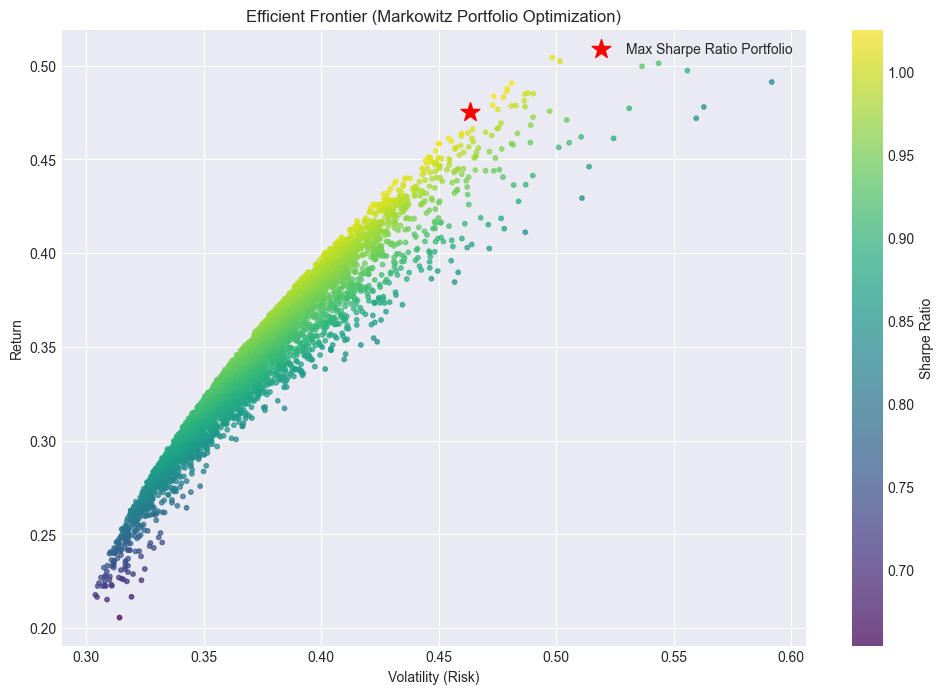

In [112]:
# 5. Visualization (Efficient Frontier) 🌈
plt.figure(figsize=(12, 8))
plt.scatter(vol_arr, ret_arr, c=sharpe_arr, cmap='viridis', s=10, alpha=0.7)
plt.colorbar(label='Sharpe Ratio')
plt.xlabel('Volatility (Risk)')
plt.ylabel('Return')
plt.title('Efficient Frontier (Markowitz Portfolio Optimization)')

# จุดที่ดีที่สุด (ดาวสีแดง)
plt.scatter(max_sr_vol, max_sr_ret, c='red', s=200, marker='*', label='Max Sharpe Ratio Portfolio')
plt.legend()
plt.show()

In [113]:
# 6. สรุปสัดส่วนการลงทุน (Asset Allocation)
print("\n--- 🏆 Best Portfolio Allocation (Max Sharpe) ---")
print(f"ผลตอบแทนคาดหวัง (Return): {max_sr_ret*100:.2f}%")
print(f"ความเสี่ยง (Volatility):   {max_sr_vol*100:.2f}%")
print(f"Sharpe Ratio: {sharpe_arr.max():.2f}")
print("-" * 30)
print("สัดส่วนที่แนะนำ:")
for i, ticker in enumerate(tickers):
    print(f"{ticker}: {best_weights[i]*100:.2f}%")


--- 🏆 Best Portfolio Allocation (Max Sharpe) ---
ผลตอบแทนคาดหวัง (Return): 47.51%
ความเสี่ยง (Volatility):   46.34%
Sharpe Ratio: 1.03
------------------------------
สัดส่วนที่แนะนำ:
NVDA: 13.68%
AAPL: 3.99%
MSFT: 1.34%
TSLA: 59.74%
GOOGL: 21.24%
